# 🔹 1. Setup & imports

In [34]:
import sys
sys.path.append("../src")
from utils import (
    set_seed,
    clinical_sanity_check,
    get_feature_groups,
    evaluate_binary_classifier
)

# ====== BASIC SETUP ======
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    RocCurveDisplay
)

import shap
from lifelines import CoxPHFitter, KaplanMeierFitter

sns.set(style="whitegrid")
np.random.seed(42)

# 🔹 2. Load and Prepare Data

In [35]:
df = pd.read_csv("../data/cirrhosis.csv")

# Convert Age from days to years
df["Age"] = df["Age"] / 365.25

# Sanity check
clinical_sanity_check(df)

# Targets
df["death"] = (df["Status"] == "D").astype(int)
survival_df = df.copy()
survival_df["event"] = (survival_df["Status"] == "D").astype(int)

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,...,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,death
0,1,400,D,D-penicillamine,58.765229,F,Y,Y,Y,Y,...,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,1
1,2,4500,C,D-penicillamine,56.446270,F,N,Y,Y,N,...,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,0
2,3,1012,D,D-penicillamine,70.072553,M,N,N,N,S,...,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,1
3,4,1925,D,D-penicillamine,54.740589,F,N,Y,Y,S,...,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,1
4,5,1504,CL,Placebo,38.105407,F,N,Y,Y,N,...,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,0


# 🔹 3. Consolidated Preprocessing & Modeling

In [36]:
# 1. Define Features
X = df.drop(columns=["ID", "Status", "death", "N_Days"])
y = df["death"]

num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(exclude=[np.number]).columns

print(f"Numeric: {list(num_features)}")
print(f"Categoric: {list(cat_features)}")

# 2. Pipeline Setup
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# 4. Fit Logistic Regression
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=500))
])
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict_proba(X_test)[:, 1]
print(f"LogReg ROC-AUC: {roc_auc_score(y_test, y_pred_lr):.4f}")

# 5. Fit Random Forest
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_test)[:, 1]
print(f"RF ROC-AUC: {roc_auc_score(y_test, y_pred_rf):.4f}")

Numeric: ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Categoric: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
LogReg ROC-AUC: 0.8727
RF ROC-AUC: 0.8700


# 🔹 4. Explainability (SHAP)

C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_8596\3538943174.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_val_to_plot, X_transformed, feature_names=feature_names)


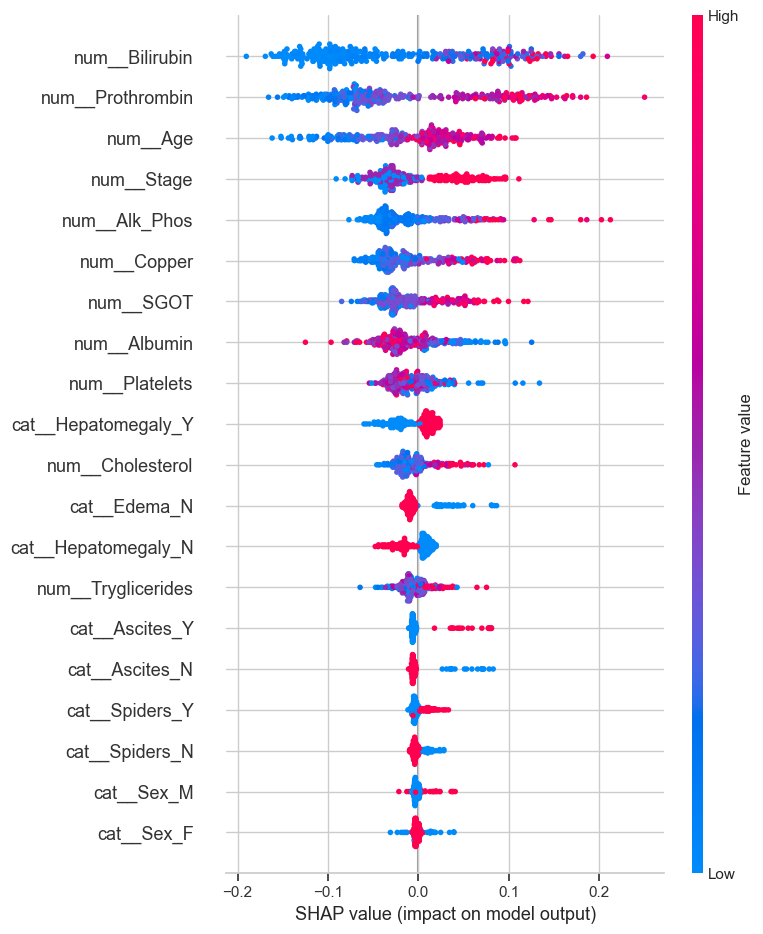

In [37]:
X_transformed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()
rf_model = rf.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_transformed)

if isinstance(shap_values, list):
    shap_val_to_plot = shap_values[1]
else:
    shap_val_to_plot = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

shap.summary_plot(shap_val_to_plot, X_transformed, feature_names=feature_names)

# 🔹 5. Survival Analysis (Cox PH)

In [38]:
cols_to_use = ["N_Days", "event"] + list(num_features) + list(cat_features)
cox_df = survival_df[cols_to_use].dropna(subset=["N_Days", "event"])

cox_data = pd.get_dummies(cox_df, columns=list(cat_features), drop_first=True, dtype=float)
cox_data = cox_data.dropna()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col="N_Days", event_col="event")
display(cph.summary)


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
Age,0.024179,1.024473,0.009313,0.005926,0.042431,1.005944,1.043344,0.0,2.596295,0.009424,6.729520
Bilirubin,0.068897,1.071326,0.021293,0.027164,0.110630,1.027536,1.116981,0.0,3.235696,0.001213,9.686651
Cholesterol,0.000445,1.000445,0.000375,-0.000290,0.001179,0.999710,1.001180,0.0,1.186205,0.235541,2.085948
Albumin,-0.614582,0.540867,0.248479,-1.101592,-0.127573,0.332342,0.880229,0.0,-2.473379,0.013384,6.223324
Copper,0.002278,1.002280,0.001011,0.000297,0.004258,1.000297,1.004267,0.0,2.253837,0.024206,5.368466
Alk_Phos,0.000011,1.000011,0.000035,-0.000058,0.000079,0.999942,1.000079,0.0,0.311878,0.755133,0.405197
SGOT,0.003014,1.003018,0.001633,-0.000188,0.006215,0.999812,1.006234,0.0,1.845123,0.065020,3.942982
Tryglicerides,-0.000153,0.999847,0.001207,-0.002519,0.002213,0.997485,1.002216,0.0,-0.126516,0.899323,0.153088
Platelets,0.000248,1.000248,0.000997,-0.001707,0.002202,0.998294,1.002205,0.0,0.248190,0.803987,0.314755


# 🔹 6. Visualization & Save

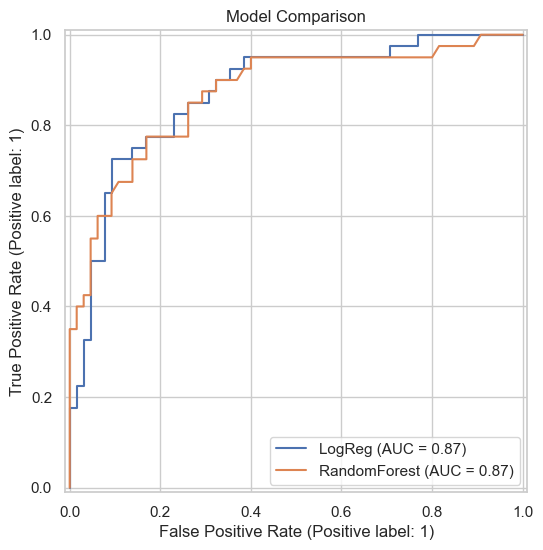

Models saved!


In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_pred_lr, name="LogReg", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_pred_rf, name="RandomForest", ax=ax)
plt.title("Model Comparison")
plt.show()

import joblib
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/rf_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")
print("Models saved!")